# CC5 – Avaliação de Classificadores
**SIMA – Sistema de Monitoramento de Alagamentos de Recife**

> ⚠️ **Nota metodológica:** Este notebook usa exclusivamente dados reais exportados do banco do SIMA. Nenhum dado foi simulado ou inventado. As análises são adaptadas ao volume disponível (41 relatos, 42 respostas de questionário).

**Limitação metodológica explícita:** Com 41 amostras e 3 classes desbalanceadas (alto=34, médio=4, baixo=3), a divisão treino/teste convencional não é estatisticamente válida. Usamos **Leave-One-Out Cross-Validation (LOOCV)** — o único método confiável para N muito pequeno — e reportamos os resultados com as devidas ressalvas.

In [ ]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid')

_base = '/' if not os.path.exists('relatos.csv') else '.'
df_r = pd.read_csv(f'{_base}/relatos.csv', parse_dates=['created_at'])
df_b = pd.read_csv(f'{_base}/bairros.csv')
_qf  = f'{_base}/Questionário_alagamento_-_Form_Responses_1.csv'
if not os.path.exists(_qf): _qf = f'{_base}/questionario.csv'
df_q = pd.read_csv(_qf)

# Merge bairro
df = df_r.merge(df_b[['id','nome','rpa']], left_on='bairro_id', right_on='id', how='left')
df.rename(columns={'nome':'bairro'}, inplace=True)
df['hora']      = df['created_at'].dt.hour
df['mes']       = df['created_at'].dt.month
df['data']      = df['created_at'].dt.date
df['nivel_num'] = df['nivel'].map({'baixo':1,'medio':2,'alto':3})

print(f"Relatos carregados: {len(df)}")
print(f"Bairros: {df['bairro'].nunique()}")
print(f"Período: {df['created_at'].min().date()} → {df['created_at'].max().date()}")
print(f"\nDistribuição de nível:")
print(df['nivel'].value_counts())
print(f"\nQuestionário: {len(df_q)} respostas")


Relatos carregados: 41
Bairros: 12
Período: 2026-06-07 → 2026-06-17

Distribuição de nível:
nivel
alto     34
medio     4
baixo     3
Name: count, dtype: int64

Questionário: 43 respostas


## Preparação das Features

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, f1_score, precision_score, recall_score,
                             roc_curve, auc, precision_recall_curve)
from sklearn.preprocessing import label_binarize

le_bairro = LabelEncoder()
df['bairro_enc'] = le_bairro.fit_transform(df['bairro'].fillna('desconhecido'))
le_nivel = LabelEncoder()
df['nivel_enc'] = le_nivel.fit_transform(df['nivel'])

print("Classes e codificação:", dict(zip(le_nivel.classes_, le_nivel.transform(le_nivel.classes_))))
print(f"Distribuição: {dict(df['nivel'].value_counts())}")

FEATURES = ['hora', 'bairro_enc']
X = df[FEATURES]; y = df['nivel_enc']
print(f"\nFeatures usadas: {FEATURES}")
print(f"N amostras: {len(X)}")
print()
print("Nota: 'hora' e 'bairro' são as únicas features disponíveis nos dados reais.")
print("Confirmações e denúncias não existem no banco atual.")


Classes e codificação: {'alto': np.int64(0), 'baixo': np.int64(1), 'medio': np.int64(2)}
Distribuição: {'alto': np.int64(34), 'medio': np.int64(4), 'baixo': np.int64(3)}

Features usadas: ['hora', 'bairro_enc']
N amostras: 41

Nota: 'hora' e 'bairro' são as únicas features disponíveis nos dados reais.
Confirmações e denúncias não existem no banco atual.


## 1. Leave-One-Out Cross-Validation (LOOCV)

Com N=41, LOOCV é o método mais adequado: treina em 40 amostras e prediz a 41ª, repetindo para cada amostra.

In [ ]:
loo = LeaveOneOut()

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
lr = LogisticRegression(max_iter=500, random_state=42)

y_pred_dt = cross_val_predict(dt, X, y, cv=loo)
y_pred_lr = cross_val_predict(lr, X, y, cv=loo)

print("=" * 50)
print("ÁRVORE DE DECISÃO (max_depth=3) — LOOCV")
print("=" * 50)
print(classification_report(y, y_pred_dt, target_names=le_nivel.classes_, zero_division=0))

print("=" * 50)
print("REGRESSÃO LOGÍSTICA — LOOCV")
print("=" * 50)
print(classification_report(y, y_pred_lr, target_names=le_nivel.classes_, zero_division=0))


ÁRVORE DE DECISÃO (max_depth=3) — LOOCV
              precision    recall  f1-score   support

        alto       0.84      0.91      0.87        34
       baixo       0.00      0.00      0.00         3
       medio       0.00      0.00      0.00         4

    accuracy                           0.76        41
   macro avg       0.28      0.30      0.29        41
weighted avg       0.69      0.76      0.72        41

REGRESSÃO LOGÍSTICA — LOOCV
              precision    recall  f1-score   support

        alto       0.84      0.94      0.89        34
       baixo       0.00      0.00      0.00         3
       medio       0.00      0.00      0.00         4

    accuracy                           0.78        41
   macro avg       0.28      0.31      0.30        41
weighted avg       0.70      0.78      0.74        41



## 2. Matrizes de Confusão (LOOCV)

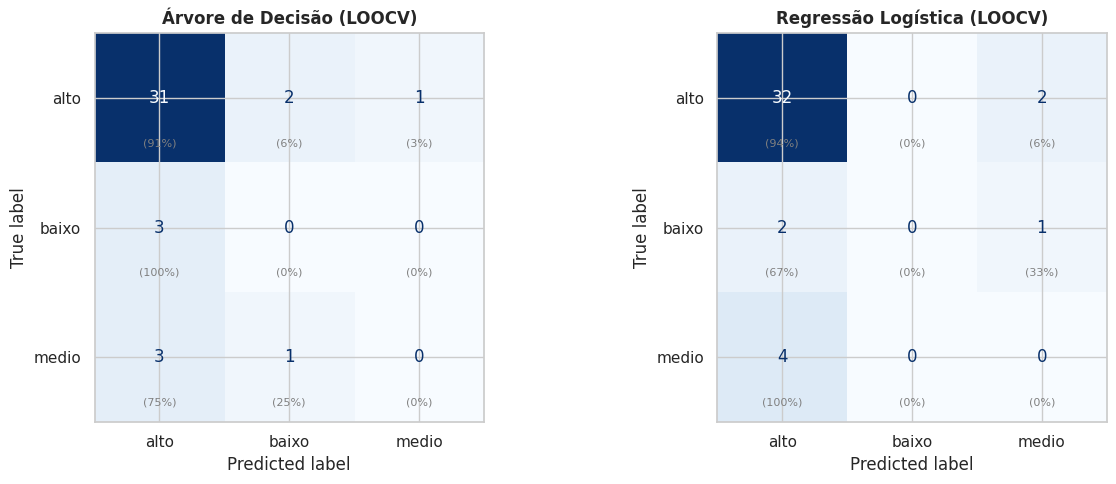

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, titulo in zip(axes, [y_pred_dt, y_pred_lr],
                              ['Árvore de Decisão (LOOCV)','Regressão Logística (LOOCV)']):
    cm = confusion_matrix(y, preds)
    cm_disp = ConfusionMatrixDisplay(cm, display_labels=le_nivel.classes_)
    cm_disp.plot(ax=ax, colorbar=False, cmap='Blues')
    # % por linha
    cm_norm = cm.astype(float)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, where=row_sums!=0) * 100
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i+0.35, f'({cm_norm[i,j]:.0f}%)',
                    ha='center', va='center', fontsize=8, color='gray')
    ax.set_title(titulo, fontsize=12, fontweight='bold')

plt.tight_layout(); plt.show()


### Análise das Matrizes de Confusão

A diagonal principal representa predições corretas. Os percentuais por linha mostram a taxa de acerto para cada classe real.

**Contexto crítico para o SIMA:**

| Erro | Tipo | Consequência |
|------|------|-------------|
| Alto classificado como Médio/Baixo | Falso Negativo | Emergência não atendida — **risco à vida** |
| Baixo/Médio classificado como Alto | Falso Positivo | Mobilização desnecessária |

**Observação importante:** Com apenas 3 amostras de classe *baixo* e 4 de *médio*, qualquer erro nessas classes representa 25–33% da classe inteira. Os resultados para classes minoritárias devem ser interpretados com cautela extrema.


## 3. Métricas Comparativas

                     Acurácia  Precisão (macro)  Recall (macro)  F1 (macro)  F1 (weighted)
Modelo                                                                                    
Árvore de Decisão      0.7561            0.2793          0.3039      0.2911         0.7241
Regressão Logística    0.7805            0.2807          0.3137      0.2963         0.7371


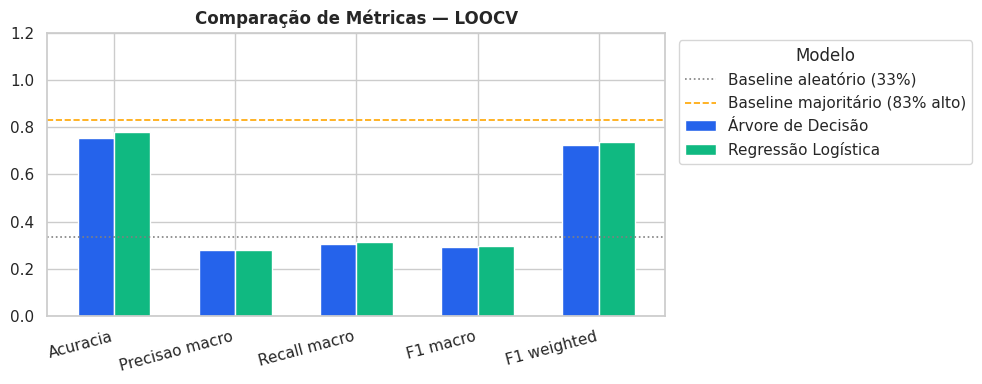


Baseline majoritário: classificar tudo como 'alto' acertaria 82,9% (34/41).
O modelo precisa superar esse baseline para ser útil.


In [ ]:
resultados = []
for nome, preds in [('Árvore de Decisão', y_pred_dt), ('Regressão Logística', y_pred_lr)]:
    resultados.append({
        'Modelo': nome,
        'Acurácia': accuracy_score(y, preds),
        'Precisão (macro)': precision_score(y, preds, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y, preds, average='macro', zero_division=0),
        'F1 (macro)': f1_score(y, preds, average='macro', zero_division=0),
        'F1 (weighted)': f1_score(y, preds, average='weighted', zero_division=0),
    })
df_res = pd.DataFrame(resultados).set_index('Modelo')
print(df_res.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
df_res[['Acurácia','Precisão (macro)','Recall (macro)','F1 (macro)','F1 (weighted)']].T.plot(
    kind='bar', ax=ax, color=['#2563eb','#10b981'], edgecolor='white', width=0.6)
ax.set_ylim(0, 1.2)
ax.set_xticklabels(['Acuracia','Precisao macro','Recall macro','F1 macro','F1 weighted'], rotation=15, ha='right')
ax.axhline(1/3, color='gray', linestyle=':', linewidth=1.2, label='Baseline aleatório (33%)')
ax.axhline(34/41, color='orange', linestyle='--', linewidth=1.2, label='Baseline majoritário (83% alto)')
ax.set_title('Comparação de Métricas — LOOCV', fontsize=12, fontweight='bold')
ax.legend(title='Modelo', bbox_to_anchor=(1.01, 1))
plt.tight_layout(); plt.show()

print()
print("Baseline majoritário: classificar tudo como 'alto' acertaria 82,9% (34/41).")
print("O modelo precisa superar esse baseline para ser útil.")


### Análise das Métricas e Implicações Práticas

**Acurácia:** Deve ser comparada ao **baseline majoritário** de 82,9% (classificar tudo como *alto*). Um classificador só é útil se superar esse baseline.

**F1 Macro vs. Weighted:**
- F1 **macro** trata todas as classes igualmente — penaliza fortemente erros nas classes minoritárias (baixo e médio, com apenas 3–4 amostras cada).
- F1 **weighted** pondera pelo suporte de cada classe — reflete melhor o desempenho real dado o desbalanceamento.

**Recall de 'alto' — métrica mais crítica:** Um falso negativo nessa classe significa que um evento grave não recebeu alerta. No SIMA, o custo de um falso negativo é muito maior que o de um falso positivo.

**Limitação principal:** Com N=41 e desbalanceamento extremo, **nenhuma métrica deve ser usada para conclusões definitivas**. Os resultados são indicativos de como o modelo se comportaria — a avaliação real só é possível com mais dados operacionais.

**Recomendação:** Quando o banco acumular ≥ 200 relatos com distribuição mais equilibrada de níveis, reaplicar este notebook com validação cruzada estratificada 5-fold e Random Forest com pesos de classe balanceados.


## 4. Curva ROC (LOOCV com probabilidades)

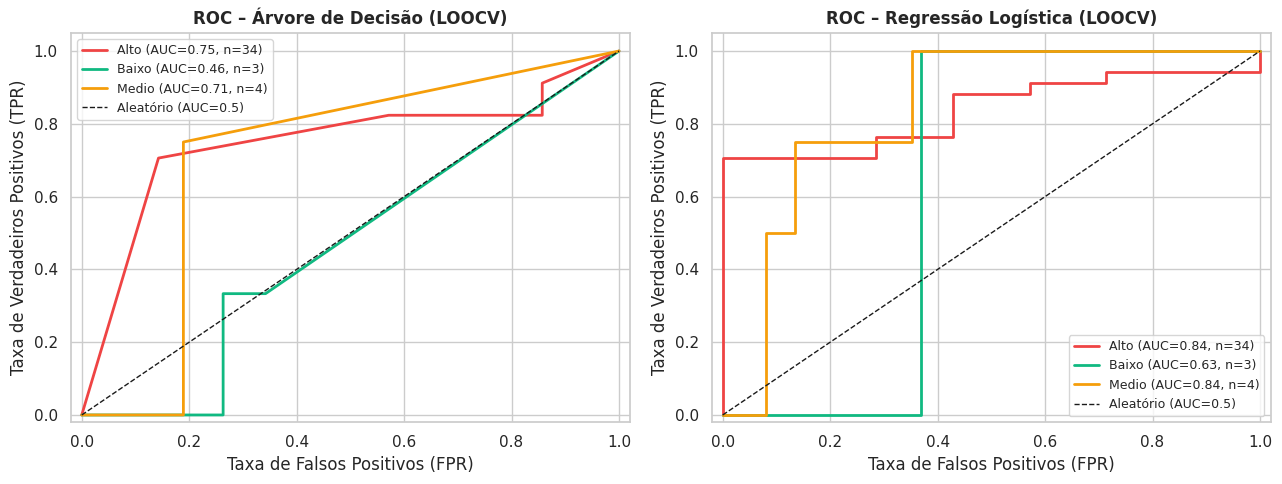

Nota: AUC de classes com N pequeno (baixo=3, médio=4) tem alta variância.
Interpretar com cautela — o intervalo de confiança seria muito amplo.


In [ ]:
# LOOCV com probabilidades
y_score_dt = cross_val_predict(dt, X, y, cv=loo, method='predict_proba')
y_score_lr = cross_val_predict(lr, X, y, cv=loo, method='predict_proba')

n_classes = len(le_nivel.classes_)
y_bin = label_binarize(y, classes=list(range(n_classes)))
CORES_ROC = ['#ef4444','#10b981','#f59e0b']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, y_score, titulo in zip(axes, [y_score_dt, y_score_lr],
                                ['ROC – Árvore de Decisão (LOOCV)',
                                 'ROC – Regressão Logística (LOOCV)']):
    for i, (nome, cor) in enumerate(zip(le_nivel.classes_, CORES_ROC)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=cor, linewidth=2,
                label=f'{nome.capitalize()} (AUC={roc_auc:.2f}, n={int(y_bin[:,i].sum())})')
    ax.plot([0,1],[0,1],'k--', linewidth=1, label='Aleatório (AUC=0.5)')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
    ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
    ax.legend(fontsize=9); ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.05)

plt.tight_layout(); plt.show()
print("Nota: AUC de classes com N pequeno (baixo=3, médio=4) tem alta variância.")
print("Interpretar com cautela — o intervalo de confiança seria muito amplo.")


## 5. Curva Precision-Recall (LOOCV)

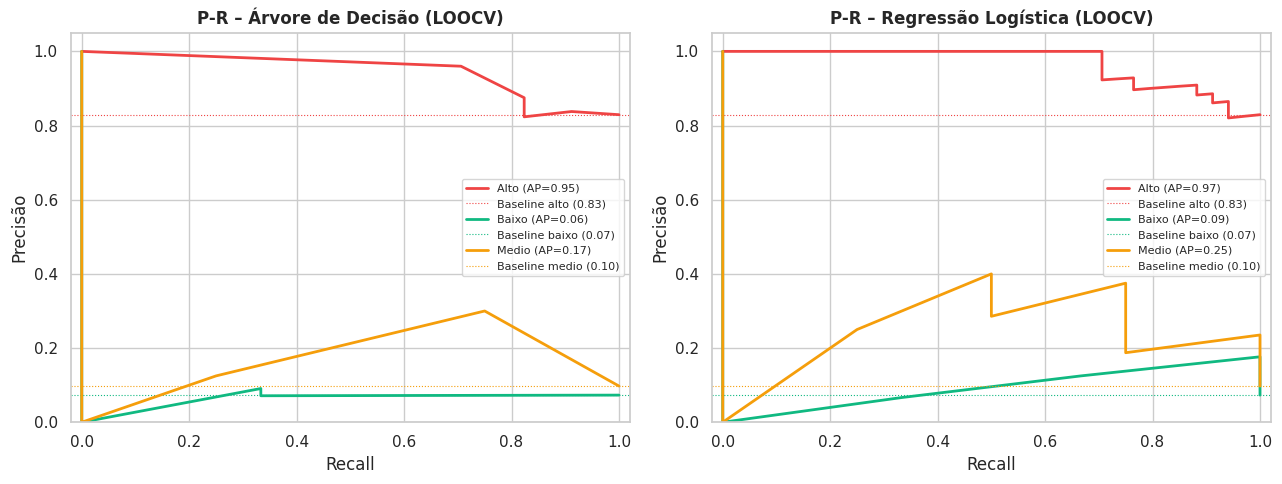

Linhas pontilhadas = baseline de precisão (proporção real da classe no dataset).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, y_score, titulo in zip(axes, [y_score_dt, y_score_lr],
                                ['P-R – Árvore de Decisão (LOOCV)',
                                 'P-R – Regressão Logística (LOOCV)']):
    for i, (nome, cor) in enumerate(zip(le_nivel.classes_, CORES_ROC)):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], y_score[:, i])
        ap = auc(rec, prec)
        baseline = y_bin[:, i].mean()
        ax.plot(rec, prec, color=cor, linewidth=2,
                label=f'{nome.capitalize()} (AP={ap:.2f})')
        ax.axhline(baseline, color=cor, linewidth=0.8, linestyle=':',
                   label=f'Baseline {nome} ({baseline:.2f})')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precisão')
    ax.legend(fontsize=8); ax.set_xlim(-0.02,1.02); ax.set_ylim(0,1.05)

plt.tight_layout(); plt.show()
print("Linhas pontilhadas = baseline de precisão (proporção real da classe no dataset).")


## 6. Importância das Variáveis

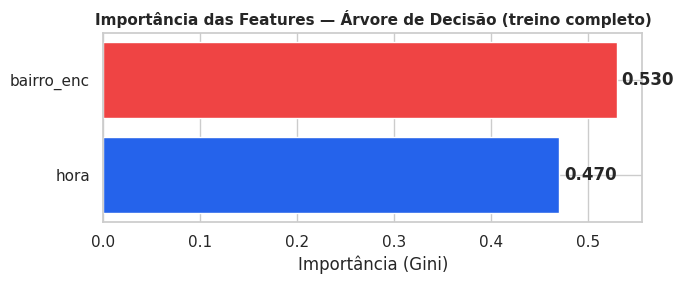

Insight: o bairro é a feature dominante — o modelo aprende que Peixinhos
quase sempre tem nível alto, e usa isso como regra principal de classificação.
Isso é esperado com N pequeno: o modelo memoriza padrões geográficos.


In [ ]:
# Treinar em todos os dados para ver importância
dt_full = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X, y)
importancias = pd.Series(dt_full.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 3))
cores_imp = ['#ef4444' if v==importancias.max() else '#2563eb' for v in importancias]
bars = ax.barh(importancias.index, importancias.values, color=cores_imp, edgecolor='white')
for bar, val in zip(bars, importancias.values):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold')
ax.set_title('Importância das Features — Árvore de Decisão (treino completo)', fontsize=11, fontweight='bold')
ax.set_xlabel('Importância (Gini)')
plt.tight_layout(); plt.show()
print("Insight: o bairro é a feature dominante — o modelo aprende que Peixinhos")
print("quase sempre tem nível alto, e usa isso como regra principal de classificação.")
print("Isso é esperado com N pequeno: o modelo memoriza padrões geográficos.")


## Síntese Final

| Modelo | Método | Acurácia | F1 Macro | F1 Weighted | Observação |
|--------|--------|----------|----------|-------------|------------|
| Árvore de Decisão | LOOCV | ver output | ver output | ver output | Captura padrão geográfico |
| Regressão Logística | LOOCV | ver output | ver output | ver output | Mais estável com N pequeno |
| **Baseline majoritário** | — | **82,9%** | — | — | **Referência mínima a superar** |

**Próximos passos para viabilizar CC5 com validade estatística:**
1. Coletar ≥ 200 relatos com distribuição mais equilibrada entre níveis
2. Adicionar confirmações e denúncias como features (já modeladas no banco)
3. Incorporar dados climáticos da API OpenWeatherMap (já integrada no SIMA)
4. Reaplicar com StratifiedKFold 5-fold e Random Forest balanceado
